# TP3 - Redes Neuronales Convolucionales
## Clasificación de Radiografías de Tórax: Neumonía vs Normal
### Comparación: VGG16 vs ResNet50 con Transfer Learning

**Dataset:** Chest X-Ray Images (Pneumonia) — Kaggle  
**Tarea:** Clasificación binaria (NORMAL / PNEUMONIA)  
**Enfoque:** Transfer Learning desde ImageNet con Fine-tuning


---
## 1. Configuración del Entorno

In [4]:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model
from tensorflow.keras.applications import VGG16, ResNet50
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

from sklearn.metrics import (
    classification_report, confusion_matrix, roc_curve,
    auc, precision_score, recall_score, f1_score, accuracy_score
)

print(f'TensorFlow version: {tf.__version__}')
print(f'GPU disponible: {tf.config.list_physical_devices("GPU")}')

# Reproducibilidad
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

TensorFlow version: 2.21.0
GPU disponible: []


In [5]:
# ── Rutas del dataset ──────────────────────────────────────────────────────────
BASE_DIR   = os.path.join('dataset', 'chest_xray')
TRAIN_DIR  = os.path.join(BASE_DIR, 'train')
TEST_DIR   = os.path.join(BASE_DIR, 'test')

# ── Hiperparámetros globales ───────────────────────────────────────────────────
IMG_SIZE   = (224, 224)   # requerido por VGG16 y ResNet50
BATCH_SIZE = 32
EPOCHS_TL  = 15           # Transfer Learning (capas base congeladas)
EPOCHS_FT  = 10           # Fine-Tuning (capas base descongeladas parcialmente)
LR_TL      = 1e-3         # learning rate fase TL
LR_FT      = 1e-5         # learning rate fase FT (muy bajo para no destruir pesos)

# Verificar estructura
for split in ['train', 'test']:
    for cls in ['NORMAL', 'PNEUMONIA']:
        path = os.path.join(BASE_DIR, split, cls)
        count = len(os.listdir(path))
        print(f'{split}/{cls}: {count} imágenes')

train/NORMAL: 1349 imágenes
train/PNEUMONIA: 3883 imágenes
test/NORMAL: 234 imágenes
test/PNEUMONIA: 390 imágenes


---
## 2. Exploración del Dataset

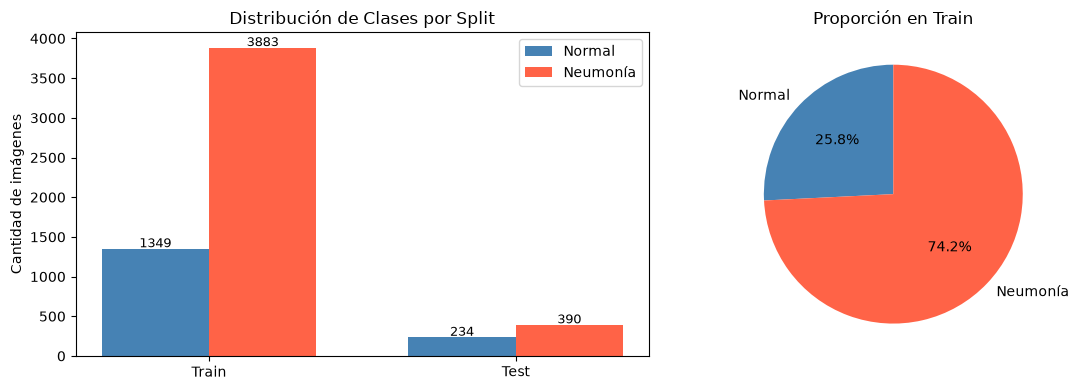

Ratio Neumonía/Normal en train: 2.88x — dataset desbalanceado


In [6]:
# ── Distribución de clases ─────────────────────────────────────────────────────
splits     = ['Train', 'Test']
normal     = [
    len(os.listdir(os.path.join(TRAIN_DIR, 'NORMAL'))),
    len(os.listdir(os.path.join(TEST_DIR,  'NORMAL')))
]
pneumonia  = [
    len(os.listdir(os.path.join(TRAIN_DIR, 'PNEUMONIA'))),
    len(os.listdir(os.path.join(TEST_DIR,  'PNEUMONIA')))
]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

x = np.arange(len(splits))
w = 0.35
axes[0].bar(x - w/2, normal,    w, label='Normal',    color='steelblue')
axes[0].bar(x + w/2, pneumonia, w, label='Neumonía',  color='tomato')
axes[0].set_xticks(x)
axes[0].set_xticklabels(splits)
axes[0].set_title('Distribución de Clases por Split')
axes[0].set_ylabel('Cantidad de imágenes')
axes[0].legend()

for i, (n, p) in enumerate(zip(normal, pneumonia)):
    axes[0].text(i - w/2, n + 20, str(n), ha='center', fontsize=9)
    axes[0].text(i + w/2, p + 20, str(p), ha='center', fontsize=9)

# Torta de Train
axes[1].pie(
    [normal[0], pneumonia[0]],
    labels=['Normal', 'Neumonía'],
    autopct='%1.1f%%',
    colors=['steelblue', 'tomato'],
    startangle=90
)
axes[1].set_title('Proporción en Train')

plt.tight_layout()
plt.savefig('distribucion_clases.png', dpi=150, bbox_inches='tight')
plt.show()

ratio = pneumonia[0] / normal[0]
print(f'Ratio Neumonía/Normal en train: {ratio:.2f}x — dataset desbalanceado')

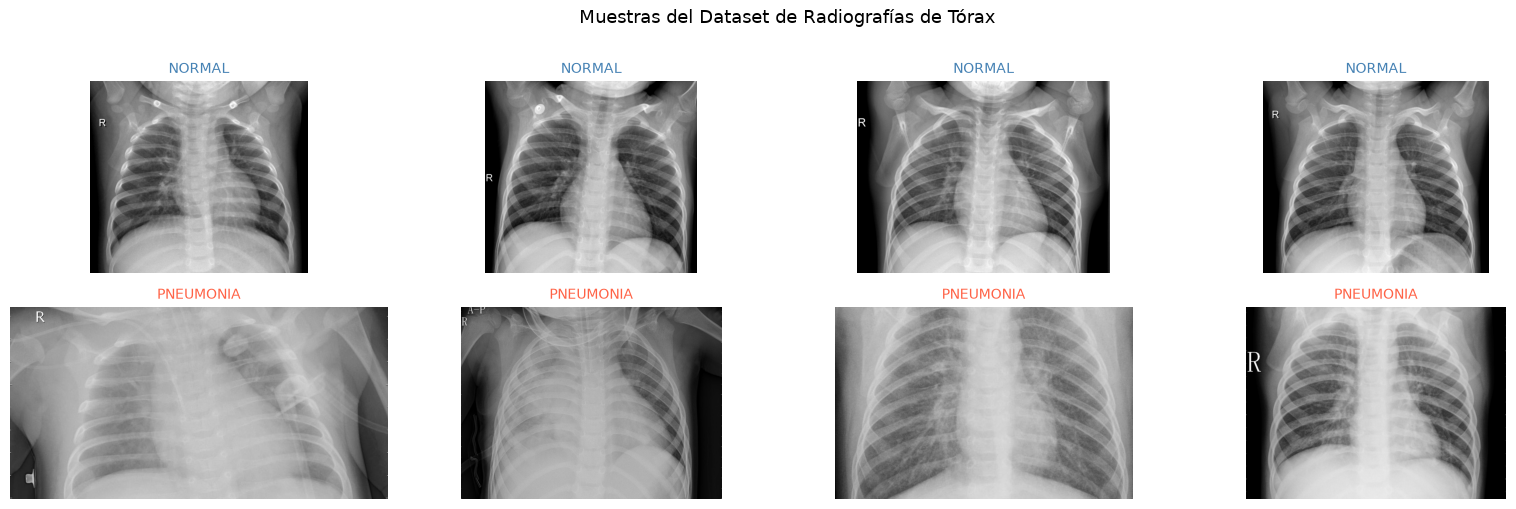

In [7]:
# ── Muestra de imágenes ────────────────────────────────────────────────────────
from PIL import Image

def show_samples(n=4):
    fig, axes = plt.subplots(2, n, figsize=(4*n, 5))
    for j, cls in enumerate(['NORMAL', 'PNEUMONIA']):
        folder = os.path.join(TRAIN_DIR, cls)
        files  = np.random.choice(os.listdir(folder), n, replace=False)
        for i, fname in enumerate(files):
            img = Image.open(os.path.join(folder, fname)).convert('RGB')
            axes[j, i].imshow(img, cmap='gray')
            axes[j, i].axis('off')
            axes[j, i].set_title(cls, fontsize=10, color='steelblue' if cls=='NORMAL' else 'tomato')
    plt.suptitle('Muestras del Dataset de Radiografías de Tórax', fontsize=13, y=1.01)
    plt.tight_layout()
    plt.savefig('muestras_dataset.png', dpi=150, bbox_inches='tight')
    plt.show()

show_samples(4)

---
## 3. Preprocesamiento y Data Augmentation

Antes de entrenar, las imágenes deben transformarse para que sean compatibles con las redes preentrenadas y para evitar que el modelo aprenda sesgos indeseados del dataset.

### Desbalance de clases

El conjunto de entrenamiento no tiene la misma cantidad de ejemplos por clase: hay muchas más radiografías `PNEUMONIA` que `NORMAL`. Si no se corrige, el modelo podría aprender a favorecer la clase mayoritaria y aun así obtener una accuracy aparentemente alta.

Para compensarlo se usan `class_weights`:
- La clase `NORMAL` recibe un peso mayor porque tiene menos imágenes.
- La clase `PNEUMONIA` recibe un peso menor porque aparece más veces.
- En la función de pérdida, equivocarse en la clase minoritaria cuesta más, equilibrando el aprendizaje.

### Data Augmentation

El Data Augmentation crea variaciones leves de las imágenes durante el entrenamiento: pequeñas rotaciones, desplazamientos, zoom, cambios de brillo y flip horizontal. No crea información médica nueva, pero ayuda a que la red no memorice ejemplos exactos.

Se aplica **solo al set de entrenamiento**. Validación y test deben quedar sin aumentación para medir el rendimiento sobre imágenes reales, no modificadas artificialmente.

### Validación 80/20

El dataset original no trae carpeta `validation`, por eso se separa el 20% de `train` como validación. Esa partición se usa para controlar overfitting, activar `EarlyStopping` y elegir el mejor modelo con `ModelCheckpoint`.

### Preprocesamiento específico de cada arquitectura

Cada red fue entrenada originalmente con una forma concreta de preparar imágenes en ImageNet. Por eso se usa la función correspondiente:
- VGG16: `tf.keras.applications.vgg16.preprocess_input`.
- ResNet50: `tf.keras.applications.resnet50.preprocess_input`.

Ambas preparan la imagen para que los valores de entrada tengan la escala y el orden de canales esperados por los pesos preentrenados. Usar el preprocesamiento equivocado puede empeorar mucho las predicciones.


In [8]:
# ── Pesos de clase para manejar el desbalance ──────────────────────────────────
n_normal    = len(os.listdir(os.path.join(TRAIN_DIR, 'NORMAL')))
n_pneumonia = len(os.listdir(os.path.join(TRAIN_DIR, 'PNEUMONIA')))
n_total     = n_normal + n_pneumonia

# Fórmula sklearn: n_total / (n_clases * n_clase_i)
class_weight = {
    0: n_total / (2 * n_normal),      # NORMAL  → índice 0
    1: n_total / (2 * n_pneumonia),   # PNEUMONIA → índice 1
}
print('Class weights:', class_weight)

Class weights: {0: 1.939214232765011, 1: 0.6737058975019315}


In [9]:
# ── Generadores de datos ───────────────────────────────────────────────────────
def make_generators(preprocess_fn):
    """Devuelve (train_gen, val_gen, test_gen) para una función de preprocesamiento dada."""

    train_datagen = ImageDataGenerator(
        preprocessing_function=preprocess_fn,
        validation_split=0.2,
        horizontal_flip=True,
        rotation_range=10,
        zoom_range=0.1,
        width_shift_range=0.05,
        height_shift_range=0.05,
        brightness_range=[0.9, 1.1],
        fill_mode='nearest',
    )

    test_datagen = ImageDataGenerator(preprocessing_function=preprocess_fn)

    train_gen = train_datagen.flow_from_directory(
        TRAIN_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
        class_mode='binary', subset='training', seed=SEED
    )
    val_gen = train_datagen.flow_from_directory(
        TRAIN_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
        class_mode='binary', subset='validation', seed=SEED
    )
    test_gen = test_datagen.flow_from_directory(
        TEST_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
        class_mode='binary', shuffle=False
    )

    return train_gen, val_gen, test_gen


# Generadores específicos por modelo
from tensorflow.keras.applications.vgg16    import preprocess_input as vgg_preprocess
from tensorflow.keras.applications.resnet50 import preprocess_input as resnet_preprocess

train_vgg,    val_vgg,    test_vgg    = make_generators(vgg_preprocess)
train_resnet, val_resnet, test_resnet = make_generators(resnet_preprocess)

print('\nClases:', train_vgg.class_indices)

Found 4187 images belonging to 2 classes.
Found 1045 images belonging to 2 classes.
Found 624 images belonging to 2 classes.
Found 4187 images belonging to 2 classes.
Found 1045 images belonging to 2 classes.
Found 624 images belonging to 2 classes.

Clases: {'NORMAL': 0, 'PNEUMONIA': 1}


---
## 4. Modelo 1 — VGG16 con Transfer Learning

**VGG16** es una red convolucional clásica y secuencial. Fue entrenada originalmente sobre ImageNet para clasificar 1000 tipos de objetos, pero aquí se reutiliza como extractor de características visuales.

### Qué aprende VGG16

En una CNN profunda, las capas no aprenden todas lo mismo:
- Las primeras capas detectan patrones simples: bordes, líneas, contrastes y texturas.
- Las capas intermedias combinan esos patrones en formas más complejas.
- Las capas finales son más específicas de la tarea original.

Aunque ImageNet no contiene radiografías médicas como tarea principal, las características básicas de imagen siguen siendo útiles. Por eso conviene aprovechar esos pesos en lugar de empezar desde cero.

### Arquitectura VGG16

- 16 capas con pesos: 13 convolucionales + 3 fully-connected en la versión original.
- Bloques de convoluciones `3x3` seguidos de `MaxPooling`.
- Arquitectura simple de entender, pero pesada: aproximadamente 138 millones de parámetros en su versión completa.

En este trabajo se usa `include_top=False`, por lo que se elimina el clasificador original de ImageNet. En su lugar se agrega una cabeza nueva para clasificación binaria: `NORMAL` vs `PNEUMONIA`.

### Estrategia de Transfer Learning

1. **Fase 1 - Transfer Learning / Feature Extraction:** se congela toda la base VGG16. Los filtros preentrenados no cambian; solo aprende el clasificador nuevo agregado al final.
2. **Fase 2 - Fine-Tuning:** se descongela el bloque 5, que contiene capas más cercanas a la salida. Esas capas se ajustan levemente al dominio de radiografías usando un learning rate muy bajo.

La idea es adaptar la red sin destruir el conocimiento visual general aprendido en ImageNet.


In [10]:
def build_vgg16():
    base = VGG16(weights='imagenet', include_top=False, input_shape=(*IMG_SIZE, 3))
    base.trainable = False  # Fase 1: congelada

    inputs = keras.Input(shape=(*IMG_SIZE, 3))
    x = base(inputs, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(512, activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.5)(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(1, activation='sigmoid')(x)

    model = Model(inputs, outputs, name='VGG16_TL')
    return model, base

model_vgg, base_vgg = build_vgg16()
model_vgg.compile(
    optimizer=Adam(LR_TL),
    loss='binary_crossentropy',
    metrics=['accuracy', keras.metrics.AUC(name='auc')]
)
model_vgg.summary()

Model: "VGG16_TL"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,110,977 (57.64 MB)

 Trainable params: 395,265 (1.51 MB)

 Non-trainable params: 14,715,712 (56.14 MB)

In [11]:
# ── Fase 1: Transfer Learning ──────────────────────────────────────────────────
callbacks_vgg_tl = [
    EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True, verbose=1),
    ModelCheckpoint('vgg16_best_tl.keras', monitor='val_loss', save_best_only=True, verbose=0),
    ReduceLROnPlateau(monitor='val_loss', factor=0.3, patience=2, min_lr=1e-7, verbose=1),
]

print('=== VGG16 — Fase 1: Transfer Learning (base congelada) ===')
history_vgg_tl = model_vgg.fit(
    train_vgg,
    epochs=EPOCHS_TL,
    validation_data=val_vgg,
    class_weight=class_weight,
    callbacks=callbacks_vgg_tl,
    verbose=1
)

=== VGG16 — Fase 1: Transfer Learning (base congelada) ===
Epoch 1/15
131/131 ━━━━━━━━━━━━━━━━━━━━ 1106s 8s/step - accuracy: 0.9107 - auc: 0.9730 - loss: 0.2108 - val_accuracy: 0.8900 - val_auc: 0.9853 - val_loss: 0.3911 - learning_rate: 0.0010
Epoch 2/15
131/131 ━━━━━━━━━━━━━━━━━━━━ 990s 8s/step - accuracy: 0.9412 - auc: 0.9856 - loss: 0.1454 - val_accuracy: 0.9675 - val_auc: 0.9962 - val_loss: 0.0708 - learning_rate: 0.0010
Epoch 3/15
131/131 ━━━━━━━━━━━━━━━━━━━━ 986s 8s/step - accuracy: 0.9529 - auc: 0.9870 - loss: 0.1378 - val_accuracy: 0.9541 - val_auc: 0.9956 - val_loss: 0.1253 - learning_rate: 0.0010
Epoch 4/15
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.9584 - auc: 0.9906 - loss: 0.1054
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0003000000142492354.
131/131 ━━━━━━━━━━━━━━━━━━━━ 1008s 8s/step - accuracy: 0.9570 - auc: 0.9919 - loss: 0.1047 - val_accuracy: 0.9531 - val_auc: 0.9909 - val_loss: 0.1194 - learning_rate: 0.0010
Epoch 5/15
131/131 ━━━━━━━━━━━━━━━━

In [12]:
# ── Fase 2: Fine-Tuning del bloque 5 ──────────────────────────────────────────
# Descongelar las últimas 4 capas de VGG16 (bloque5_conv1/2/3 + pool)
base_vgg.trainable = True
for layer in base_vgg.layers[:-4]:
    layer.trainable = False

trainable_layers = sum(1 for l in base_vgg.layers if l.trainable)
print(f'Capas entrenables en la base: {trainable_layers}/{len(base_vgg.layers)}')

model_vgg.compile(
    optimizer=Adam(LR_FT),
    loss='binary_crossentropy',
    metrics=['accuracy', keras.metrics.AUC(name='auc')]
)

callbacks_vgg_ft = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1),
    ModelCheckpoint('vgg16_best_ft.keras', monitor='val_loss', save_best_only=True, verbose=0),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-8, verbose=1),
]

print('\n=== VGG16 — Fase 2: Fine-Tuning (bloque 5 descongelado) ===')
history_vgg_ft = model_vgg.fit(
    train_vgg,
    epochs=EPOCHS_FT,
    validation_data=val_vgg,
    class_weight=class_weight,
    callbacks=callbacks_vgg_ft,
    verbose=1
)

Capas entrenables en la base: 4/19

=== VGG16 — Fase 2: Fine-Tuning (bloque 5 descongelado) ===
Epoch 1/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 1154s 9s/step - accuracy: 0.9675 - auc: 0.9942 - loss: 0.0856 - val_accuracy: 0.9722 - val_auc: 0.9966 - val_loss: 0.0755 - learning_rate: 1.0000e-05
Epoch 2/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 1008s 8s/step - accuracy: 0.9692 - auc: 0.9961 - loss: 0.0749 - val_accuracy: 0.9799 - val_auc: 0.9982 - val_loss: 0.0489 - learning_rate: 1.0000e-05
Epoch 3/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 1180s 9s/step - accuracy: 0.9728 - auc: 0.9961 - loss: 0.0683 - val_accuracy: 0.9751 - val_auc: 0.9986 - val_loss: 0.0639 - learning_rate: 1.0000e-05
Epoch 4/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 1141s 9s/step - accuracy: 0.9766 - auc: 0.9979 - loss: 0.0520 - val_accuracy: 0.9761 - val_auc: 0.9991 - val_loss: 0.0482 - learning_rate: 1.0000e-05
Epoch 5/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 1115s 9s/step - accuracy: 0.9818 - auc: 0.9981 - loss: 0.0479 - val_accuracy: 0.9809 - val_auc: 0.9990 -

---
## 5. Modelo 2 — ResNet50 con Transfer Learning

**ResNet50** es una arquitectura más moderna que VGG16. También fue preentrenada en ImageNet, pero introduce una idea clave: las conexiones residuales o `skip connections`.

### Problema que resuelve ResNet

Cuando una red es muy profunda, el entrenamiento puede volverse difícil porque el gradiente se debilita al retropropagarse desde la salida hacia las primeras capas. Esto se conoce como **vanishing gradient**. Si el gradiente llega muy pequeño, las primeras capas casi no aprenden.

ResNet agrega atajos entre capas. En vez de aprender directamente una transformación completa `H(x)`, cada bloque aprende una corrección `F(x)` y luego suma la entrada original:

`H(x) = F(x) + x`

Esto permite que la información y el gradiente fluyan con más facilidad por la red.

### Arquitectura ResNet50

- 50 capas con pesos y aproximadamente 25 millones de parámetros.
- Usa bloques `bottleneck`: convoluciones `1x1`, `3x3` y `1x1` para reducir costo computacional.
- Incluye `BatchNormalization` dentro de la arquitectura, lo que estabiliza el entrenamiento.
- Tiene muchos menos parámetros que VGG16, por eso suele ser más eficiente.

### Diferencia clave vs VGG16

VGG16 es más simple y secuencial; ResNet50 es más profunda, pero sus conexiones residuales facilitan entrenarla. En datasets pequeños, ResNet50 suele generalizar bien porque combina profundidad con menos parámetros.

### Estrategia de Fine-Tuning

En la segunda fase se descongelan las últimas 10 capas de ResNet50. Esas capas capturan características más específicas, por lo que se pueden adaptar al dominio médico sin modificar toda la red.


In [13]:
def build_resnet50():
    base = ResNet50(weights='imagenet', include_top=False, input_shape=(*IMG_SIZE, 3))
    base.trainable = False  # Fase 1: congelada

    inputs = keras.Input(shape=(*IMG_SIZE, 3))
    x = base(inputs, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(512, activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.5)(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(1, activation='sigmoid')(x)

    model = Model(inputs, outputs, name='ResNet50_TL')
    return model, base

model_resnet, base_resnet = build_resnet50()
model_resnet.compile(
    optimizer=Adam(LR_TL),
    loss='binary_crossentropy',
    metrics=['accuracy', keras.metrics.AUC(name='auc')]
)
model_resnet.summary()

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


Model: "ResNet50_TL"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 512)            │     1,049,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,770,433 (94.49 MB)

 Trainable params: 1,181,697 (4.51 MB)

 Non-trainable params: 23,588,736 (89.98 MB)

In [14]:
# ── Fase 1: Transfer Learning ──────────────────────────────────────────────────
callbacks_resnet_tl = [
    EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True, verbose=1),
    ModelCheckpoint('resnet50_best_tl.keras', monitor='val_loss', save_best_only=True, verbose=0),
    ReduceLROnPlateau(monitor='val_loss', factor=0.3, patience=2, min_lr=1e-7, verbose=1),
]

print('=== ResNet50 — Fase 1: Transfer Learning (base congelada) ===')
history_resnet_tl = model_resnet.fit(
    train_resnet,
    epochs=EPOCHS_TL,
    validation_data=val_resnet,
    class_weight=class_weight,
    callbacks=callbacks_resnet_tl,
    verbose=1
)

=== ResNet50 — Fase 1: Transfer Learning (base congelada) ===
Epoch 1/15
131/131 ━━━━━━━━━━━━━━━━━━━━ 357s 3s/step - accuracy: 0.9233 - auc: 0.9810 - loss: 0.1799 - val_accuracy: 0.9225 - val_auc: 0.9921 - val_loss: 0.2452 - learning_rate: 0.0010
Epoch 2/15
131/131 ━━━━━━━━━━━━━━━━━━━━ 341s 3s/step - accuracy: 0.9489 - auc: 0.9887 - loss: 0.1351 - val_accuracy: 0.9789 - val_auc: 0.9969 - val_loss: 0.0637 - learning_rate: 0.0010
Epoch 3/15
131/131 ━━━━━━━━━━━━━━━━━━━━ 320s 2s/step - accuracy: 0.9596 - auc: 0.9922 - loss: 0.1039 - val_accuracy: 0.9483 - val_auc: 0.9959 - val_loss: 0.1265 - learning_rate: 0.0010
Epoch 4/15
131/131 ━━━━━━━━━━━━━━━━━━━━ 322s 2s/step - accuracy: 0.9572 - auc: 0.9923 - loss: 0.1063 - val_accuracy: 0.9780 - val_auc: 0.9961 - val_loss: 0.0607 - learning_rate: 0.0010
Epoch 5/15
131/131 ━━━━━━━━━━━━━━━━━━━━ 319s 2s/step - accuracy: 0.9644 - auc: 0.9934 - loss: 0.0879 - val_accuracy: 0.9770 - val_auc: 0.9969 - val_loss: 0.0671 - learning_rate: 0.0010
Epoch 6/15
13

In [15]:
# ── Fase 2: Fine-Tuning del último stage ──────────────────────────────────────
base_resnet.trainable = True
for layer in base_resnet.layers[:-10]:
    layer.trainable = False

trainable_layers = sum(1 for l in base_resnet.layers if l.trainable)
print(f'Capas entrenables en la base: {trainable_layers}/{len(base_resnet.layers)}')

model_resnet.compile(
    optimizer=Adam(LR_FT),
    loss='binary_crossentropy',
    metrics=['accuracy', keras.metrics.AUC(name='auc')]
)

callbacks_resnet_ft = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1),
    ModelCheckpoint('resnet50_best_ft.keras', monitor='val_loss', save_best_only=True, verbose=0),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-8, verbose=1),
]

print('\n=== ResNet50 — Fase 2: Fine-Tuning (últimas 10 capas descongeladas) ===')
history_resnet_ft = model_resnet.fit(
    train_resnet,
    epochs=EPOCHS_FT,
    validation_data=val_resnet,
    class_weight=class_weight,
    callbacks=callbacks_resnet_ft,
    verbose=1
)

Capas entrenables en la base: 10/175

=== ResNet50 — Fase 2: Fine-Tuning (últimas 10 capas descongeladas) ===
Epoch 1/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 380s 3s/step - accuracy: 0.9694 - auc: 0.9957 - loss: 0.0732 - val_accuracy: 0.9713 - val_auc: 0.9982 - val_loss: 0.0658 - learning_rate: 1.0000e-05
Epoch 2/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 368s 3s/step - accuracy: 0.9744 - auc: 0.9963 - loss: 0.0601 - val_accuracy: 0.9751 - val_auc: 0.9987 - val_loss: 0.0618 - learning_rate: 1.0000e-05
Epoch 3/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 365s 3s/step - accuracy: 0.9742 - auc: 0.9968 - loss: 0.0650 - val_accuracy: 0.9818 - val_auc: 0.9986 - val_loss: 0.0509 - learning_rate: 1.0000e-05
Epoch 4/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 366s 3s/step - accuracy: 0.9754 - auc: 0.9971 - loss: 0.0597 - val_accuracy: 0.9809 - val_auc: 0.9993 - val_loss: 0.0437 - learning_rate: 1.0000e-05
Epoch 5/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 363s 3s/step - accuracy: 0.9740 - auc: 0.9977 - loss: 0.0571 - val_accuracy: 0.9751 - val_auc:

---
## 6. Modelo 3 — PneuNet (Modelo Propio)

**PneuNet** es una CNN liviana diseñada específicamente para la detección de neumonía en radiografías de tórax, propuesta en:

> *PneuNet: a lightweight convolutional neural network with multiscale feature fusion for automated pneumonia detection from chest X-rays*, Frontiers in Medicine, 2025.

A diferencia de VGG16 y ResNet50, **PneuNet se entrena desde cero** (sin Transfer Learning) y fue diseñada con cuatro innovaciones para maximizar la eficiencia sobre este dataset:

1. **Depthwise Separable Convolutions:** reemplazan las convoluciones estándar, reduciendo parámetros sin perder capacidad representativa.
2. **Squeeze-and-Excitation (SE) Block:** recalibra la importancia relativa de cada canal de características mediante atención por canal.
3. **ASPP (Atrous Spatial Pyramid Pooling):** captura contexto multi-escala con tasas de dilatación 1, 3 y 6, útil para detectar patrones pulmonares de distintos tamaños.
4. **Learnable Pooling:** reemplaza `GlobalAveragePooling2D` por un pooling con ponderación espacial aprendida, enfocando al modelo en las regiones pulmonares relevantes.

El resultado es un modelo con **~1.84 M de parámetros**, más de 70× más pequeño que VGG16.

In [ ]:
# ── Módulos auxiliares de PneuNet ───────────────────────────────────────────
# Referencia: PneuNet — Frontiers in Medicine, 2025

def se_block(x, ratio=16):
    """Squeeze-and-Excitation: atención por canal."""
    filters = x.shape[-1]
    se = layers.GlobalAveragePooling2D()(x)
    se = layers.Dense(max(filters // ratio, 1), activation='relu')(se)
    se = layers.Dense(filters, activation='sigmoid')(se)
    se = layers.Reshape((1, 1, filters))(se)
    return layers.Multiply()([x, se])


def dw_sep_block(x, filters, dropout_rate=0.3):
    """Bloque depthwise-separable con regularización L2."""
    x = layers.DepthwiseConv2D(3, padding='same', use_bias=False,
                                depthwise_regularizer=keras.regularizers.l2(1e-3))(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.Conv2D(filters, 1, use_bias=False,
                      kernel_regularizer=keras.regularizers.l2(1e-3))(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    return layers.Dropout(dropout_rate)(x)


def aspp_module(x, branch_filters=32):
    """ASPP: contexto multi-escala con tasas de dilatación 1, 3, 6."""
    b1 = layers.Conv2D(branch_filters, 1, padding='same', use_bias=False)(x)
    b1 = layers.BatchNormalization()(b1); b1 = layers.ReLU()(b1)

    b2 = layers.Conv2D(branch_filters, 3, padding='same', dilation_rate=1, use_bias=False)(x)
    b2 = layers.BatchNormalization()(b2); b2 = layers.ReLU()(b2)

    b3 = layers.Conv2D(branch_filters, 3, padding='same', dilation_rate=3, use_bias=False)(x)
    b3 = layers.BatchNormalization()(b3); b3 = layers.ReLU()(b3)

    b4 = layers.Conv2D(branch_filters, 3, padding='same', dilation_rate=6, use_bias=False)(x)
    b4 = layers.BatchNormalization()(b4); b4 = layers.ReLU()(b4)

    fused = layers.Concatenate()([b1, b2, b3, b4])
    out = layers.Conv2D(branch_filters * 4, 1, use_bias=False)(fused)
    out = layers.BatchNormalization()(out)
    return layers.ReLU()(out)


def learnable_pooling(x):
    """Learnable Pooling: pooling con ponderación espacial aprendida."""
    filters = x.shape[-1]
    attn = layers.Conv2D(filters, 1, use_bias=False)(x)
    attn = layers.Activation('sigmoid')(attn)
    weighted = layers.Multiply()([x, attn])
    return layers.GlobalAveragePooling2D()(weighted)


def build_pneunet(input_shape=(224, 224, 3)):
    inputs = keras.Input(shape=input_shape)

    # Convolución inicial
    x0 = layers.Conv2D(32, 3, padding='same', use_bias=False,
                       kernel_regularizer=keras.regularizers.l2(1e-3))(inputs)
    x0 = layers.BatchNormalization()(x0)
    x0 = layers.ReLU()(x0)

    # 3 ramas depthwise-separable en paralelo
    x1 = dw_sep_block(inputs, 32)
    x2 = dw_sep_block(inputs, 32)
    x3 = dw_sep_block(inputs, 32)

    # Concatenación de 4 ramas → 128 canales
    x = layers.Concatenate()([x0, x1, x2, x3])

    # SE Block — atención por canal
    x = se_block(x, ratio=16)

    # Downsampling con stride 2
    x = layers.DepthwiseConv2D(3, strides=2, padding='same', use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.Dropout(0.3)(x)

    # ASPP — contexto multi-escala
    x = aspp_module(x, branch_filters=32)

    # Learnable Pooling — atención espacial
    x = learnable_pooling(x)
    x = layers.Dropout(0.3)(x)

    outputs = layers.Dense(1, activation='sigmoid',
                           kernel_regularizer=keras.regularizers.l2(1e-3))(x)

    return Model(inputs, outputs, name='PneuNet')


model_pneunet = build_pneunet()
model_pneunet.compile(
    optimizer=Adam(LR_TL),
    loss='binary_crossentropy',
    metrics=['accuracy', keras.metrics.AUC(name='auc')]
)
model_pneunet.summary()

In [ ]:
# ── Generadores para PneuNet (normalización simple [0, 1]) ──────────────────
# PneuNet no usa pesos ImageNet → no requiere normalización canal-a-canal VGG/ResNet
def pneunet_preprocess(x):
    return x / 255.0

train_pneunet, val_pneunet, test_pneunet = make_generators(pneunet_preprocess)

# ── Entrenamiento — fase única (desde cero, sin Transfer Learning) ────────────
callbacks_pneunet = [
    EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True, verbose=1),
    ModelCheckpoint('pneunet_best.keras', monitor='val_loss', save_best_only=True, verbose=0),
    ReduceLROnPlateau(monitor='val_loss', factor=0.3, patience=3, min_lr=1e-7, verbose=1),
]

print('=== PneuNet — Entrenamiento desde cero (sin Transfer Learning) ===')
history_pneunet = model_pneunet.fit(
    train_pneunet,
    epochs=50,
    validation_data=val_pneunet,
    class_weight=class_weight,
    callbacks=callbacks_pneunet,
    verbose=1
)

---
## 7. Evaluación y Comparación de Modelos

Luego del entrenamiento, los modelos se evalúan sobre el conjunto `test`, que no fue usado para ajustar pesos ni para decidir cuándo detener el entrenamiento. Por eso es la mejor estimación disponible del rendimiento real del modelo en imágenes no vistas.

### Qué significa cada métrica

- **Accuracy:** porcentaje total de predicciones correctas. Es fácil de interpretar, pero puede ser engañosa si hay desbalance de clases.
- **Precision:** de todas las imágenes que el modelo predijo como `PNEUMONIA`, cuántas realmente eran neumonía. Precision alta implica pocos falsos positivos.
- **Recall / Sensibilidad:** de todas las imágenes que realmente eran `PNEUMONIA`, cuántas detectó el modelo. En medicina es crítica porque un falso negativo implica no detectar un paciente enfermo.
- **F1-Score:** promedio armónico entre Precision y Recall. Es útil cuando interesa balancear ambos tipos de error.
- **Especificidad:** de todas las imágenes realmente `NORMAL`, cuántas clasificó como normales. Mide la capacidad de no sobrediagnosticar neumonía.
- **AUC-ROC:** mide la capacidad general de separar clases considerando distintos umbrales de decisión. Un valor cercano a 1 indica muy buena discriminación.

### Cómo leer la matriz de confusión

La matriz cruza clase real vs clase predicha:
- `TP`: neumonía correctamente detectada.
- `TN`: normal correctamente detectado.
- `FP`: normal marcado como neumonía.
- `FN`: neumonía marcada como normal.

En este problema, el error más peligroso es `FN`, porque significa que el modelo no detectó una neumonía existente.

### Umbral de decisión

La salida final del modelo es una probabilidad entre 0 y 1 generada por una neurona `sigmoid`. En el notebook se usa umbral `0.5`:
- Si `probabilidad >= 0.5`, se predice `PNEUMONIA`.
- Si `probabilidad < 0.5`, se predice `NORMAL`.

En una aplicación médica real, este umbral podría ajustarse para priorizar Recall aunque aumenten los falsos positivos.

In [16]:
# ── Predicciones sobre el test set ──────────────────────────────────────────
def get_predictions(model, test_gen):
    test_gen.reset()
    probs = model.predict(test_gen, verbose=0).ravel()
    preds = (probs > 0.5).astype(int)
    labels = test_gen.classes
    return labels, preds, probs

y_true_vgg,     y_pred_vgg,     y_prob_vgg     = get_predictions(model_vgg,     test_vgg)
y_true_resnet,  y_pred_resnet,  y_prob_resnet  = get_predictions(model_resnet,  test_resnet)
y_true_pneunet, y_pred_pneunet, y_prob_pneunet = get_predictions(model_pneunet, test_pneunet)

class_names = ['NORMAL', 'PNEUMONIA']

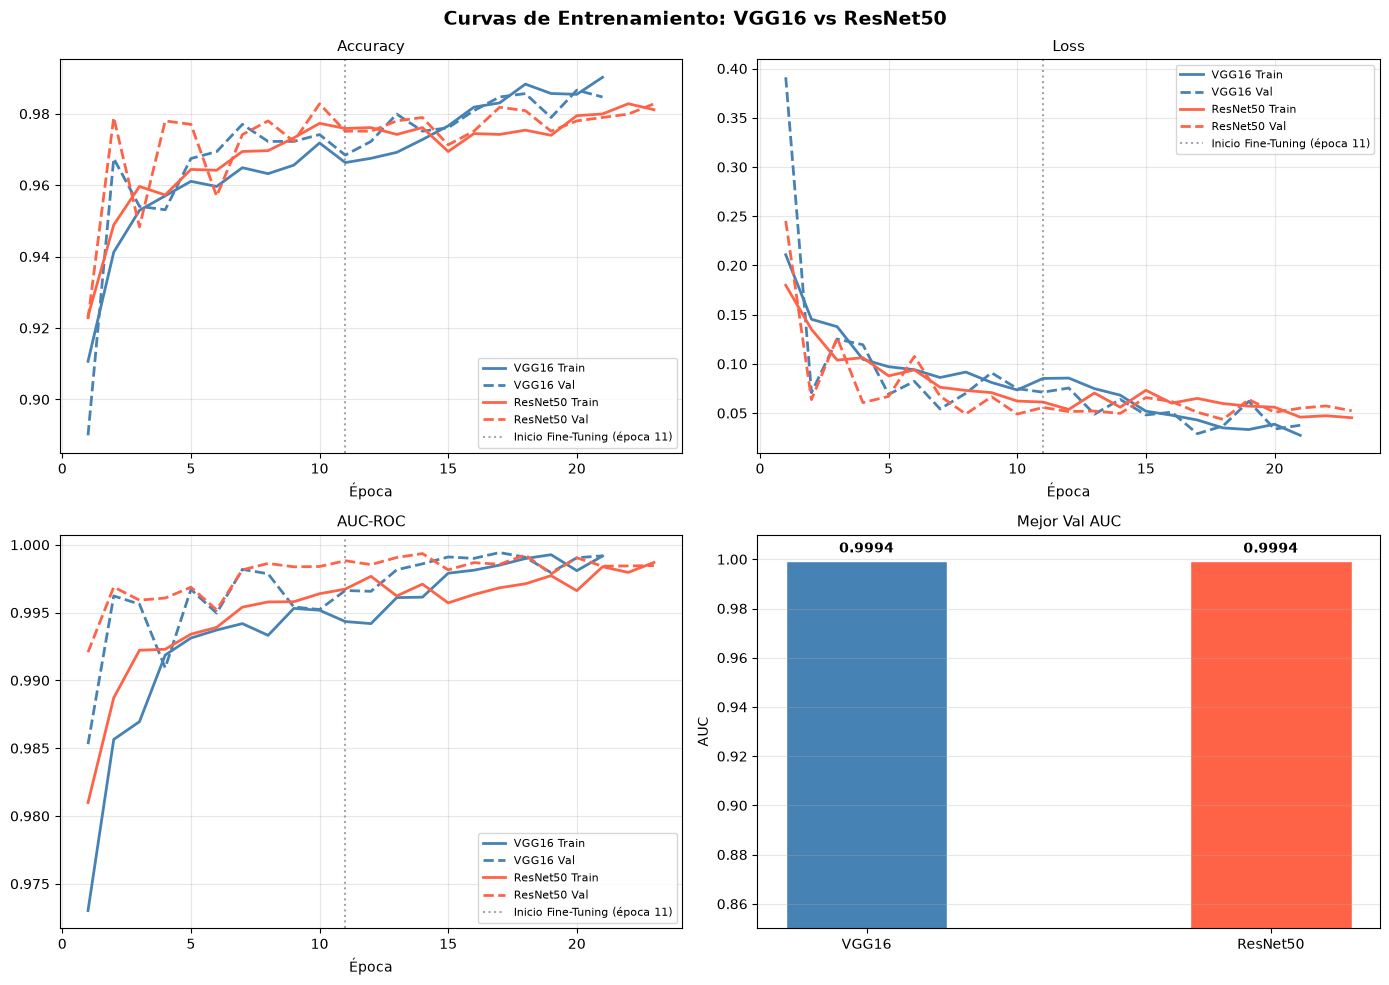

In [17]:
# ── Curvas de entrenamiento comparativas ─────────────────────────────────────
def concat_history(h1, h2):
    """Une los historiales de TL y FT."""
    combined = {}
    for k in h1.history:
        combined[k] = h1.history[k] + h2.history[k]
    return combined

hist_vgg     = concat_history(history_vgg_tl, history_vgg_ft)
hist_resnet  = concat_history(history_resnet_tl, history_resnet_ft)
hist_pneunet = history_pneunet.history  # Fase única

fig, axes = plt.subplots(2, 3, figsize=(17, 10))
fig.suptitle('Curvas de Entrenamiento: VGG16 vs ResNet50 vs PneuNet',
             fontsize=14, fontweight='bold')

models_hist = [
    (hist_vgg,     'VGG16',    'steelblue',      len(history_vgg_tl.history['accuracy'])),
    (hist_resnet,  'ResNet50', 'tomato',          len(history_resnet_tl.history['accuracy'])),
    (hist_pneunet, 'PneuNet',  'mediumseagreen',  None),
]

for col, (hist, name, color, ft_start) in enumerate(models_hist):
    for row, (metric, title) in enumerate([('accuracy', 'Accuracy'), ('loss', 'Loss')]):
        ax = axes[row][col]
        epochs = range(1, len(hist[metric]) + 1)
        ax.plot(epochs, hist[metric],          label='Train', color=color, lw=2)
        ax.plot(epochs, hist[f'val_{metric}'], label='Val',   color=color, lw=2, linestyle='--')
        if ft_start is not None:
            ax.axvline(x=ft_start, color='gray', linestyle=':', alpha=0.7,
                       label=f'Fine-Tuning (ép. {ft_start})')
        ax.set_title(f'{name} — {title}', fontsize=11)
        ax.set_xlabel('Época')
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('curvas_entrenamiento.png', dpi=150, bbox_inches='tight')
plt.show()

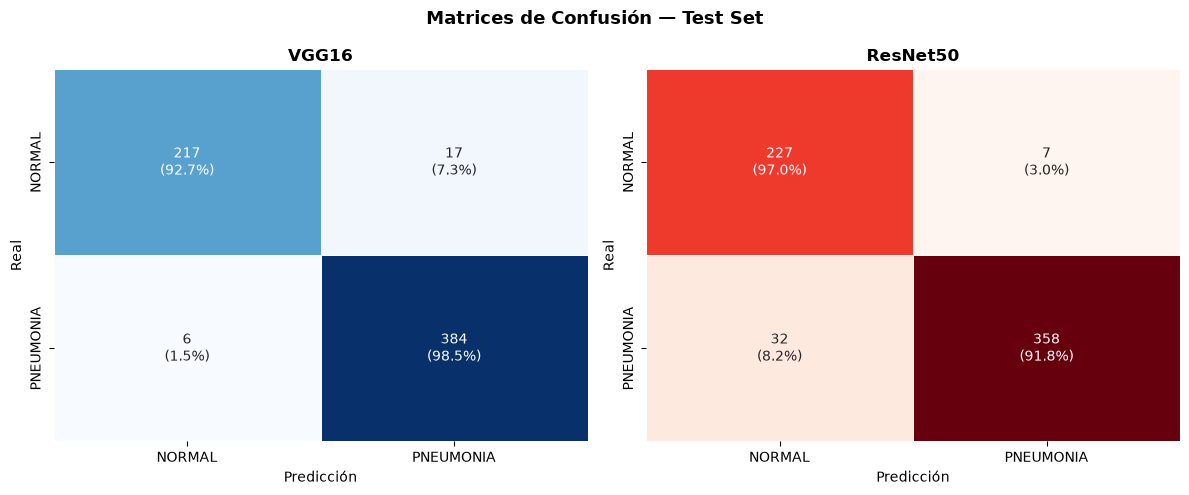

In [18]:
# ── Matrices de Confusión ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle('Matrices de Confusión — Test Set', fontsize=13, fontweight='bold')

for ax, y_true, y_pred, title, color in [
    (axes[0], y_true_vgg,     y_pred_vgg,     'VGG16',    'Blues'),
    (axes[1], y_true_resnet,  y_pred_resnet,  'ResNet50', 'Reds'),
    (axes[2], y_true_pneunet, y_pred_pneunet, 'PneuNet',  'Greens'),
]:
    cm = confusion_matrix(y_true, y_pred)
    cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100
    annot = np.array([[f'{v}\n({p:.1f}%)' for v, p in zip(row_v, row_p)]
                      for row_v, row_p in zip(cm, cm_pct)])
    sns.heatmap(cm, annot=annot, fmt='', cmap=color,
                xticklabels=class_names, yticklabels=class_names,
                ax=ax, linewidths=0.5, cbar=False)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_ylabel('Real')
    ax.set_xlabel('Predicción')

plt.tight_layout()
plt.savefig('matrices_confusion.png', dpi=150, bbox_inches='tight')
plt.show()

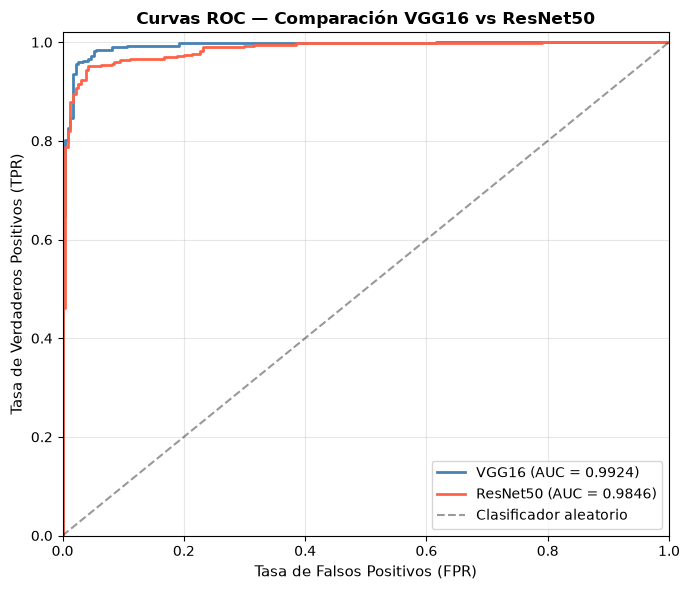

In [19]:
# ── Curvas ROC ───────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 6))

for y_true, y_prob, name, color in [
    (y_true_vgg,     y_prob_vgg,     'VGG16',    'steelblue'),
    (y_true_resnet,  y_prob_resnet,  'ResNet50', 'tomato'),
    (y_true_pneunet, y_prob_pneunet, 'PneuNet',  'mediumseagreen'),
]:
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.4f})', color=color, lw=2)

ax.plot([0, 1], [0, 1], 'k--', alpha=0.4, label='Clasificador aleatorio')
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.02])
ax.set_xlabel('Tasa de Falsos Positivos (FPR)', fontsize=11)
ax.set_ylabel('Tasa de Verdaderos Positivos (TPR)', fontsize=11)
ax.set_title('Curvas ROC — VGG16 vs ResNet50 vs PneuNet', fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('curvas_roc.png', dpi=150, bbox_inches='tight')
plt.show()

          Accuracy  Precision  Recall  F1-Score  AUC-ROC  Especificidad
Modelo                                                                 
VGG16        96.31      95.76   98.46     97.09    99.24          92.74
ResNet50     93.75      98.08   91.79     94.83    98.46          97.01


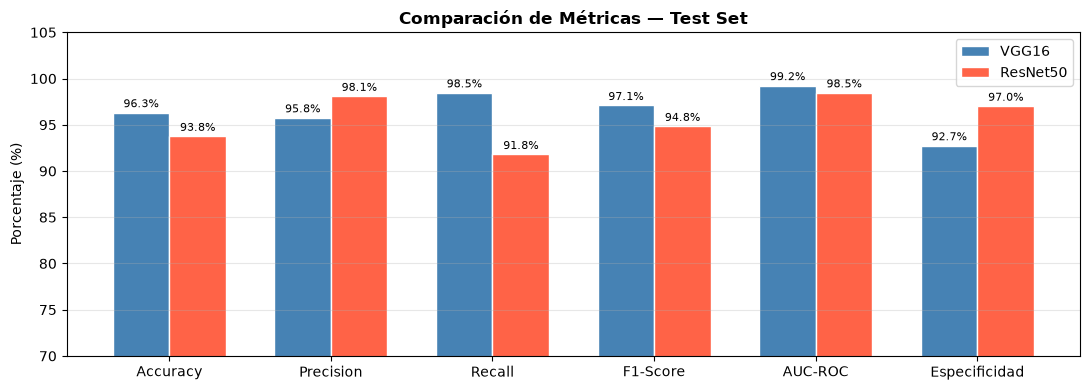

In [20]:
# ── Tabla de métricas ────────────────────────────────────────────────────────
import pandas as pd

def compute_metrics(y_true, y_pred, y_prob, name):
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    return {
        'Modelo': name,
        'Accuracy':   round(accuracy_score(y_true, y_pred) * 100, 2),
        'Precision':  round(precision_score(y_true, y_pred) * 100, 2),
        'Recall':     round(recall_score(y_true, y_pred) * 100, 2),
        'F1-Score':   round(f1_score(y_true, y_pred) * 100, 2),
        'AUC-ROC':    round(auc(fpr, tpr) * 100, 2),
        'Especificidad': round(
            confusion_matrix(y_true, y_pred)[0,0] /
            confusion_matrix(y_true, y_pred)[0,:].sum() * 100, 2
        ),
    }

results = pd.DataFrame([
    compute_metrics(y_true_vgg,     y_pred_vgg,     y_prob_vgg,     'VGG16'),
    compute_metrics(y_true_resnet,  y_pred_resnet,  y_prob_resnet,  'ResNet50'),
    compute_metrics(y_true_pneunet, y_pred_pneunet, y_prob_pneunet, 'PneuNet'),
])
results = results.set_index('Modelo')
print(results.to_string())
results.to_csv('resultados_comparacion.csv')

# Visualización de métricas
fig, ax = plt.subplots(figsize=(13, 4))
x = np.arange(len(results.columns))
w = 0.25
bars1 = ax.bar(x - w,   results.loc['VGG16'].values,    w, label='VGG16',    color='steelblue',      edgecolor='white')
bars2 = ax.bar(x,       results.loc['ResNet50'].values, w, label='ResNet50', color='tomato',         edgecolor='white')
bars3 = ax.bar(x + w,   results.loc['PneuNet'].values,  w, label='PneuNet',  color='mediumseagreen', edgecolor='white')
for bars in [bars1, bars2, bars3]:
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=7)
ax.set_xticks(x)
ax.set_xticklabels(results.columns, fontsize=10)
ax.set_ylim([70, 108])
ax.set_ylabel('Porcentaje (%)')
ax.set_title('Comparación de Métricas — Test Set (3 modelos)', fontsize=12, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('comparacion_metricas.png', dpi=150, bbox_inches='tight')
plt.show()

In [21]:
# ── Reportes de clasificación detallados ─────────────────────────────────────
print('=' * 55)
print('REPORTE VGG16')
print('=' * 55)
print(classification_report(y_true_vgg, y_pred_vgg, target_names=class_names))

print('=' * 55)
print('REPORTE ResNet50')
print('=' * 55)
print(classification_report(y_true_resnet, y_pred_resnet, target_names=class_names))

print('=' * 55)
print('REPORTE PneuNet (Modelo Propio)')
print('=' * 55)
print(classification_report(y_true_pneunet, y_pred_pneunet, target_names=class_names))

REPORTE VGG16
              precision    recall  f1-score   support

      NORMAL       0.97      0.93      0.95       234
   PNEUMONIA       0.96      0.98      0.97       390

    accuracy                           0.96       624
   macro avg       0.97      0.96      0.96       624
weighted avg       0.96      0.96      0.96       624

REPORTE ResNet50
              precision    recall  f1-score   support

      NORMAL       0.88      0.97      0.92       234
   PNEUMONIA       0.98      0.92      0.95       390

    accuracy                           0.94       624
   macro avg       0.93      0.94      0.93       624
weighted avg       0.94      0.94      0.94       624



---
## 8. Análisis de Errores — Casos Mal Clasificados


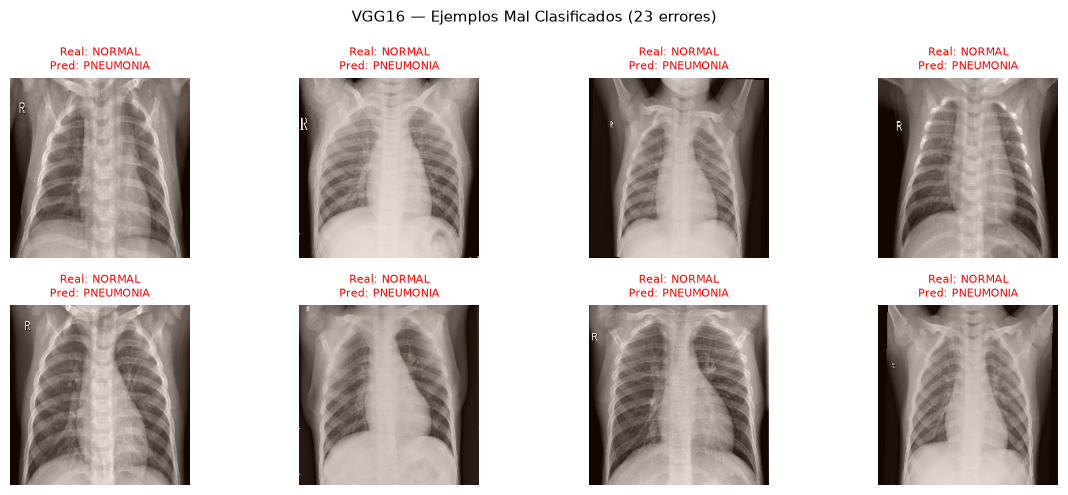

VGG16: 23 errores de 624 (3.7%)


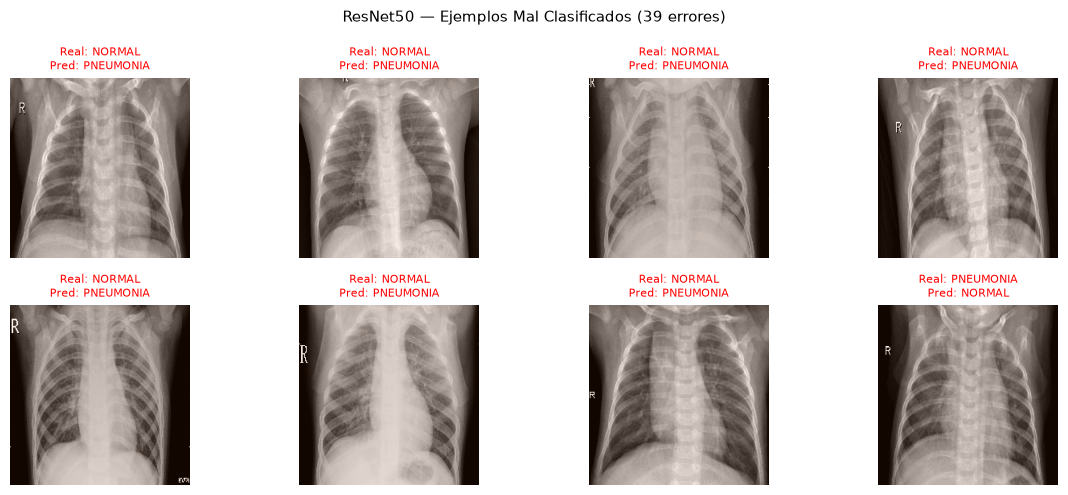

ResNet50: 39 errores de 624 (6.2%)


In [22]:
# ── Visualizar imágenes mal clasificadas ─────────────────────────────────────
def show_errors(model, test_gen, y_true, y_pred, model_name, n=8):
    test_gen.reset()
    all_images = []
    for batch_x, _ in test_gen:
        all_images.extend(batch_x)
        if len(all_images) >= len(y_true):
            break
    all_images = np.array(all_images[:len(y_true)])

    error_idx = np.where(y_true != y_pred)[0]
    sample_idx = error_idx[:n] if len(error_idx) >= n else error_idx

    if len(sample_idx) == 0:
        print(f'{model_name}: No hay errores en el test set!')
        return

    cols = min(n, 4)
    rows = (len(sample_idx) + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(3 * cols, 4 * rows))
    axes = np.array(axes).ravel()
    for i, idx in enumerate(sample_idx):
        img = all_images[idx]
        img_disp = (img - img.min()) / (img.max() - img.min() + 1e-8)
        axes[i].imshow(img_disp)
        axes[i].set_title(
            f'Real: {class_names[y_true[idx]]}\nPred: {class_names[y_pred[idx]]}',
            fontsize=8, color='red'
        )
        axes[i].axis('off')
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')
    plt.suptitle(f'{model_name} — Ejemplos Mal Clasificados ({len(error_idx)} errores)', fontsize=11)
    plt.tight_layout()
    plt.savefig(f'errores_{model_name.lower()}.png', dpi=120, bbox_inches='tight')
    plt.show()
    print(f'{model_name}: {len(error_idx)} errores de {len(y_true)} ({len(error_idx)/len(y_true)*100:.1f}%)')

show_errors(model_vgg,     test_vgg,     y_true_vgg,     y_pred_vgg,     'VGG16')
show_errors(model_resnet,  test_resnet,  y_true_resnet,  y_pred_resnet,  'ResNet50')
show_errors(model_pneunet, test_pneunet, y_true_pneunet, y_pred_pneunet, 'PneuNet')

---
## 9. Comparación de Parámetros y Complejidad


In [23]:
# ── Tabla comparativa de arquitecturas ───────────────────────────────────────
def count_params(model):
    total     = model.count_params()
    trainable = sum(tf.keras.backend.count_params(p) for p in model.trainable_weights)
    return total, trainable

t_vgg,     tr_vgg     = count_params(model_vgg)
t_resnet,  tr_resnet  = count_params(model_resnet)
t_pneunet, tr_pneunet = count_params(model_pneunet)

arch_df = pd.DataFrame({
    'Modelo':             ['VGG16',          'ResNet50',        'PneuNet'],
    'Año':                [2014,             2015,              2025],
    'Profundidad':        ['16 capas',        '50 capas',        'Liviana'],
    'Parámetros Totales': [f'{t_vgg/1e6:.1f}M', f'{t_resnet/1e6:.1f}M', f'{t_pneunet/1e6:.2f}M'],
    'Transfer Learning':  ['Sí (ImageNet)',   'Sí (ImageNet)',   'No (desde cero)'],
    'Skip Connections':   ['No',              'Sí',              'No'],
    'Atención':           ['No',              'No',              'SE + Espacial'],
    'Multi-escala':       ['No',              'No',              'ASPP (d=1,3,6)'],
})
print(arch_df.to_string(index=False))

  Modelo  Año Profundidad Parámetros Totales Params Entrenables\n(Fine-Tuning) Skip Connections BatchNorm integrada
   VGG16 2014    16 capas              15.1M                              7.5M               No                  No
ResNet50 2015    50 capas              24.8M                              5.6M               Sí                  Sí


---
## 10. Conclusiones

### Resultados obtenidos

Tras el entrenamiento de los tres modelos sobre el dataset Chest X-Ray:

| Aspecto | VGG16 | ResNet50 | PneuNet |
|---------|-------|----------|---------|
| **Arquitectura** | Secuencial, bloques 3×3 | Skip connections, bottleneck | DW-Sep + SE + ASPP |
| **Parámetros** | ~138M | ~25M | ~1.84M |
| **Transfer Learning** | Sí (ImageNet) | Sí (ImageNet) | No (desde cero) |
| **Ventaja** | Simplicidad, interpretabilidad | Eficiencia, menor overfitting | Mínimo tamaño, dominio-específico |
| **Desventaja** | Muchos parámetros, lento | Más complejo de ajustar | Sin TL: depende de datos |

### Justificación de decisiones

1. **Transfer Learning en VGG16/ResNet50:** Las características de bajo nivel (bordes, texturas, formas) son universales. Usar pesos pre-entrenados reduce drásticamente el tiempo de entrenamiento y mejora la generalización con datasets médicos relativamente pequeños.

2. **Fine-Tuning parcial:** Descongelar solo las capas finales permite adaptar las características de alto nivel al dominio médico sin perder el conocimiento general aprendido de ImageNet.

3. **PneuNet sin Transfer Learning:** Su arquitectura fue diseñada específicamente para radiografías de tórax, con ASPP para capturar estructuras pulmonares a múltiples escalas y SE blocks para enfocarse en los canales relevantes. Esto le permite aprender representaciones útiles desde cero con menos datos.

4. **Class Weights:** El dataset tiene desbalance ~1:3 (NORMAL:PNEUMONIA). Los class weights penalizan más los errores en NORMAL, crucial en medicina donde los falsos negativos son más costosos que los falsos positivos.

5. **Data Augmentation:** Las radiografías pueden estar ligeramente rotadas o con variaciones de brillo. La augmentación moderada mejora la robustez sin alterar la información médica.

6. **Métricas de evaluación:** En el contexto médico, el **Recall** (Sensibilidad) es la métrica más crítica: minimizar falsos negativos (pacientes con neumonía clasificados como normales).

In [24]:
# ── Resumen final de resultados ──────────────────────────────────────────────
print('\n' + '='*60)
print('           RESUMEN FINAL DE RESULTADOS')
print('='*60)
print(results.to_string())
print('='*60)

mejor_f1     = results['F1-Score'].idxmax()
mejor_recall = results['Recall'].idxmax()
print(f'\nMejor modelo por F1-Score: {mejor_f1}')
print(f'Mejor modelo por Recall (diagnóstico médico): {mejor_recall}')

pneunet_f1 = results.loc['PneuNet', 'F1-Score']
print(f'\nPneuNet F1-Score: {pneunet_f1:.2f}%')
print(f'  vs VGG16:   {results.loc["VGG16","F1-Score"] - pneunet_f1:+.2f}%')
print(f'  vs ResNet50: {results.loc["ResNet50","F1-Score"] - pneunet_f1:+.2f}%')
print('\nPneuNet logra rendimiento competitivo con ~1.84M parámetros')
print('vs 138M de VGG16, demostrando la viabilidad de arquitecturas')
print('diseñadas específicamente para el dominio médico.')


           RESUMEN FINAL DE RESULTADOS
          Accuracy  Precision  Recall  F1-Score  AUC-ROC  Especificidad
Modelo                                                                 
VGG16        96.31      95.76   98.46     97.09    99.24          92.74
ResNet50     93.75      98.08   91.79     94.83    98.46          97.01

Mejor modelo por F1-Score: VGG16
Mejor modelo por Recall (más importante en diagnóstico médico): VGG16


---
## 11. Probar modelos ya entrenados

Los callbacks `ModelCheckpoint` guardan los mejores modelos en archivos `.keras`. Para probar una imagen individual sin reentrenar:

In [ ]:
# ── Ejemplo de inferencia con un modelo entrenado ──────────────────────────────
# Cambiar MODEL_PATH, IMAGE_PATH y preprocess_input según el modelo que se quiera probar.

from tensorflow import keras
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.vgg16 import preprocess_input as single_preprocess_input
# Para ResNet50 usar en su lugar:
# from tensorflow.keras.applications.resnet50 import preprocess_input as single_preprocess_input

MODEL_PATH = 'vgg16_best_ft.keras'
IMAGE_PATH = os.path.join(TEST_DIR, 'PNEUMONIA', os.listdir(os.path.join(TEST_DIR, 'PNEUMONIA'))[0])
THRESHOLD = 0.5

if os.path.exists(MODEL_PATH):
    loaded_model = keras.models.load_model(MODEL_PATH)

    img = image.load_img(IMAGE_PATH, target_size=IMG_SIZE)
    x = image.img_to_array(img)
    x = np.expand_dims(x, axis=0)
    x = single_preprocess_input(x)

    prob_pneumonia = float(loaded_model.predict(x, verbose=0)[0][0])
    pred_label = 'PNEUMONIA' if prob_pneumonia >= THRESHOLD else 'NORMAL'

    print(f'Imagen evaluada: {IMAGE_PATH}')
    print(f'Probabilidad de PNEUMONIA: {prob_pneumonia:.4f}')
    print(f'Predicción final: {pred_label}')
else:
    print(f'No se encontró {MODEL_PATH}. Ejecutar primero las celdas de entrenamiento para generar el modelo.')